# Manual Circle Fit

Assume Qc is fixed, and diameter of complex circle indicate Q/Qc.

The resonance frequency is the oppsite side along the complex circle relative to the off-resonance side.

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


def read_s21_csv(filename):
    data = pd.read_csv(filename, header=None)

    freq = data.iloc[:, 0].to_numpy(dtype=float)
    mag_db = data.iloc[:, 1].to_numpy(dtype=float)
    phase_deg = data.iloc[:, 2].to_numpy(dtype=float)

    mag_linear = 10 ** (mag_db / 20)
    phase_rad = np.deg2rad(phase_deg)

    s21_real = mag_linear * np.cos(phase_rad)
    s21_imag = mag_linear * np.sin(phase_rad)
    s21_complex = s21_real + 1j * s21_imag

    return freq, s21_real, s21_imag, s21_complex


def circle_residual(params, x, y):
    xc, yc, r = params
    return np.sqrt((x - xc) ** 2 + (y - yc) ** 2) - r


def fit_circle(x, y):
    xc0 = np.mean(x)
    yc0 = np.mean(y)
    r0 = np.mean(np.sqrt((x - xc0) ** 2 + (y - yc0) ** 2))

    result = least_squares(
        circle_residual,
        x0=[xc0, yc0, r0],
        args=(x, y),
    )

    xc, yc, r = result.x
    return xc, yc, abs(r), result


def find_opposite_frequency(freq, s21_complex, xc, yc, r, f_low, f_high):
    center = xc + 1j * yc

    idx_low = np.argmin(np.abs(freq - f_low))
    idx_high = np.argmin(np.abs(freq - f_high))

    z_low = s21_complex[idx_low]
    z_high = s21_complex[idx_high]

    z_avg = 0.5 * (z_low + z_high)

    direction = z_avg - center
    direction_norm = np.abs(direction)

    if direction_norm == 0:
        raise ValueError("The averaged bound point is exactly at the circle center.")

    unit_direction = direction / direction_norm

    # Opposite-side intersection on the fitted circle
    z_opposite = center - r * unit_direction

    distances = np.abs(s21_complex - z_opposite)
    idx_closest = np.argmin(distances)

    return {
        "idx_low": idx_low,
        "idx_high": idx_high,
        "f_low_actual": freq[idx_low],
        "f_high_actual": freq[idx_high],
        "z_low": z_low,
        "z_high": z_high,
        "z_avg": z_avg,
        "z_opposite": z_opposite,
        "idx_closest": idx_closest,
        "f_closest": freq[idx_closest],
        "z_closest": s21_complex[idx_closest],
    }


def plot_circle_fit(freq, s21_complex, xc, yc, r, opposite_result=None):
    x = s21_complex.real
    y = s21_complex.imag
    center = xc + 1j * yc

    plt.figure(figsize=(7, 7))

    plt.plot(x, y, "o", markersize=3, label="S21 data")

    theta = np.linspace(0, 2 * np.pi, 800)
    circle = center + r * np.exp(1j * theta)

    plt.plot(circle.real, circle.imag, "-", label="Circle fit")
    plt.plot(xc, yc, "x", markersize=10, label="Circle center")

    if opposite_result is not None:
        z_low = opposite_result["z_low"]
        z_high = opposite_result["z_high"]
        z_avg = opposite_result["z_avg"]
        z_opposite = opposite_result["z_opposite"]
        z_closest = opposite_result["z_closest"]

        plt.plot(z_low.real, z_low.imag, "s", label="Low-bound point")
        plt.plot(z_high.real, z_high.imag, "s", label="High-bound point")
        plt.plot(z_avg.real, z_avg.imag, "D", label="Average bound point")
        plt.plot(z_opposite.real, z_opposite.imag, "*", markersize=14,
                 label="Opposite circle intersection")
        plt.plot(z_closest.real, z_closest.imag, "P", markersize=10,
                 label="Closest measured point")

        plt.plot(
            [z_avg.real, z_opposite.real],
            [z_avg.imag, z_opposite.imag],
            "--",
            label="Line through center",
        )

    plt.xlabel("Re(S21)")
    plt.ylabel("Im(S21)")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

fc = 4250794578 Hz
Q = 120284
Qi = 127982


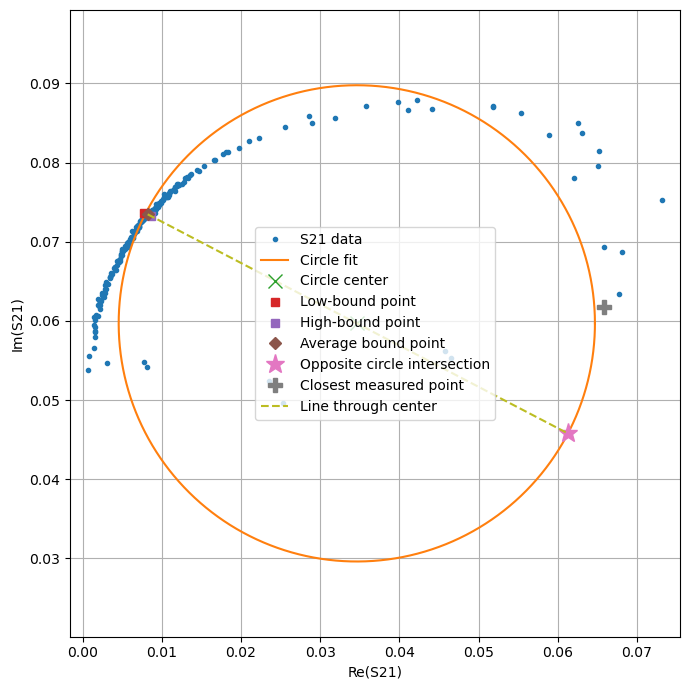

In [73]:
if __name__ == "__main__":

    import os

    folder_path = r"C:\Users\user\Documents\GitHub\Measurements\Cooldown_77_Line4-MQC_Ta_Qc2M_01\Broadband"
    filename = "MQC_Ta_Qc2M_01_4p251GHz_-30dBm_15mK.csv"

    full_path = os.path.join(folder_path, filename)

    freq, s21_real, s21_imag, s21_complex = read_s21_csv(full_path)

    xc, yc, r, fit_result = fit_circle(s21_real, s21_imag)

    # print("Circle fit result:")
    # print(f"xc = {xc:.6e}")
    # print(f"yc = {yc:.6e}")
    # print(f"r  = {r:.6e}")

    f_low = freq[0]
    f_high = freq[-1]

    opposite_result = find_opposite_frequency(
        freq=freq,
        s21_complex=s21_complex,
        xc=xc,
        yc=yc,
        r=r,
        f_low=f_low,
        f_high=f_high,
    )

    Q_over_Qc = 2*r
    Qc = 2e6 # UPDATE!
    Q = Q_over_Qc * Qc
    Qi = (1/Q - 1/Qc)**(-1)

    # print("\nBound-frequency points:")
    # print(f"Requested f_low  = {f_low:.9e} Hz")
    # print(f"Actual f_low     = {opposite_result['f_low_actual']:.9e} Hz")
    # print(f"Requested f_high = {f_high:.9e} Hz")
    # print(f"Actual f_high    = {opposite_result['f_high_actual']:.9e} Hz")

    print(f"fc = {opposite_result['f_closest']:.0f} Hz")
    print(f"Q = {Q:.0f}")
    print(f"Qi = {Qi:.0f}")

    plot_circle_fit(
        freq=freq,
        s21_complex=s21_complex,
        xc=xc,
        yc=yc,
        r=r,
        opposite_result=opposite_result,
    )

# Ver. 2.0 Manual Circle Fit

In [74]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


def read_s21_csv(filename):
    data = pd.read_csv(filename, header=None)

    freq = data.iloc[:, 0].to_numpy(dtype=float)
    mag_db = data.iloc[:, 1].to_numpy(dtype=float)
    phase_deg = data.iloc[:, 2].to_numpy(dtype=float)

    mag_linear = 10 ** (mag_db / 20)
    phase_rad = np.deg2rad(phase_deg)

    s21_real = mag_linear * np.cos(phase_rad)
    s21_imag = mag_linear * np.sin(phase_rad)
    s21_complex = s21_real + 1j * s21_imag

    return freq, s21_real, s21_imag, s21_complex


def circle_residual(params, x, y):
    xc, yc, r = params
    return np.sqrt((x - xc) ** 2 + (y - yc) ** 2) - r


def fit_circle(x, y):
    xc0 = np.mean(x)
    yc0 = np.mean(y)
    r0 = np.mean(np.sqrt((x - xc0) ** 2 + (y - yc0) ** 2))

    result = least_squares(
        circle_residual,
        x0=[xc0, yc0, r0],
        args=(x, y),
    )

    xc, yc, r = result.x
    r = abs(r)

    # Estimate parameter covariance
    residual = result.fun
    n_data = len(residual)
    n_param = len(result.x)

    if n_data > n_param:
        dof = n_data - n_param
        residual_var = np.sum(residual ** 2) / dof

        try:
            jac = result.jac
            cov = residual_var * np.linalg.inv(jac.T @ jac)
            r_unc = np.sqrt(cov[2, 2])
        except np.linalg.LinAlgError:
            r_unc = np.nan
    else:
        r_unc = np.nan

    diameter = 2 * r
    diameter_unc = 2 * r_unc

    return xc, yc, r, r_unc, diameter, diameter_unc, result


def find_opposite_frequency(freq, s21_complex, xc, yc, r, f_low, f_high):
    center = xc + 1j * yc

    idx_low = np.argmin(np.abs(freq - f_low))
    idx_high = np.argmin(np.abs(freq - f_high))

    z_low = s21_complex[idx_low]
    z_high = s21_complex[idx_high]
    z_avg = 0.5 * (z_low + z_high)

    direction = z_avg - center
    direction_norm = np.abs(direction)

    if direction_norm == 0:
        raise ValueError("The averaged bound point is exactly at the circle center.")

    unit_direction = direction / direction_norm

    z_opposite = center - r * unit_direction

    distances = np.abs(s21_complex - z_opposite)
    idx_closest = np.argmin(distances)

    return {
        "idx_low": idx_low,
        "idx_high": idx_high,
        "f_low_actual": freq[idx_low],
        "f_high_actual": freq[idx_high],
        "z_low": z_low,
        "z_high": z_high,
        "z_avg": z_avg,
        "z_opposite": z_opposite,
        "idx_closest": idx_closest,
        "f_closest": freq[idx_closest],
        "z_closest": s21_complex[idx_closest],
    }


def extract_power_from_filename(filename):
    """
    Extract power like -65dBm, -30dBm, -00dBm from filename.
    """
    base = os.path.basename(filename)

    match = re.search(r"(-?\d+(?:\.\d+)?)dBm", base)

    if match is None:
        return np.nan

    return float(match.group(1))


def calculate_q_values(r, r_unc, Qc):
    diameter = 2 * r
    diameter_unc = 2 * r_unc

    Q = diameter * Qc
    Q_unc = diameter_unc * Qc

    Qi = (1 / Q - 1 / Qc) ** (-1)

    # Propagate uncertainty from Q to Qi
    # Qi = 1 / (1/Q - 1/Qc)
    dQi_dQ = Qi ** 2 / Q ** 2
    Qi_unc = abs(dQi_dQ) * Q_unc

    return diameter, diameter_unc, Q, Q_unc, Qi, Qi_unc


def plot_circle_fit(freq, s21_complex, xc, yc, r, opposite_result=None, title=None):
    x = s21_complex.real
    y = s21_complex.imag
    center = xc + 1j * yc

    plt.figure(figsize=(7, 7))
    plt.plot(x, y, "o", markersize=3, label="S21 data")

    theta = np.linspace(0, 2 * np.pi, 800)
    circle = center + r * np.exp(1j * theta)

    plt.plot(circle.real, circle.imag, "-", label="Circle fit")
    plt.plot(xc, yc, "x", markersize=10, label="Circle center")

    if opposite_result is not None:
        z_low = opposite_result["z_low"]
        z_high = opposite_result["z_high"]
        z_avg = opposite_result["z_avg"]
        z_opposite = opposite_result["z_opposite"]
        z_closest = opposite_result["z_closest"]

        plt.plot(z_low.real, z_low.imag, "s", label="Low-bound point")
        plt.plot(z_high.real, z_high.imag, "s", label="High-bound point")
        plt.plot(z_avg.real, z_avg.imag, "D", label="Average bound point")
        plt.plot(z_opposite.real, z_opposite.imag, "*", markersize=14,
                 label="Opposite circle intersection")
        plt.plot(z_closest.real, z_closest.imag, "P", markersize=10,
                 label="Closest measured point")

        plt.plot(
            [z_avg.real, z_opposite.real],
            [z_avg.imag, z_opposite.imag],
            "--",
            label="Line through center",
        )

    plt.xlabel("Re(S21)")
    plt.ylabel("Im(S21)")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    if title is not None:
        plt.title(title)

    plt.tight_layout()
    plt.show()


def fit_single_file(filepath, Qc, draw_circle=False):
    freq, s21_real, s21_imag, s21_complex = read_s21_csv(filepath)

    xc, yc, r, r_unc, diameter, diameter_unc, fit_result = fit_circle(
        s21_real,
        s21_imag,
    )

    f_low = freq[0]
    f_high = freq[-1]

    opposite_result = find_opposite_frequency(
        freq=freq,
        s21_complex=s21_complex,
        xc=xc,
        yc=yc,
        r=r,
        f_low=f_low,
        f_high=f_high,
    )

    diameter, diameter_unc, Q, Q_unc, Qi, Qi_unc = calculate_q_values(
        r=r,
        r_unc=r_unc,
        Qc=Qc,
    )

    power = extract_power_from_filename(filepath)

    if draw_circle:
        plot_circle_fit(
            freq=freq,
            s21_complex=s21_complex,
            xc=xc,
            yc=yc,
            r=r,
            opposite_result=opposite_result,
            title=os.path.basename(filepath),
        )

    return {
        "filename": os.path.basename(filepath),
        "power_dBm": power,
        "fc_Hz": opposite_result["f_closest"],
        "xc": xc,
        "yc": yc,
        "r": r,
        "r_unc": r_unc,
        "diameter": diameter,
        "diameter_unc": diameter_unc,
        "Q": Q,
        "Q_unc": Q_unc,
        "Qi": Qi,
        "Qi_unc": Qi_unc,
        "fit_success": fit_result.success,
    }


def fit_folder(folder_path, Qc, draw_each_circle=False):
    csv_files = get_raw_vna_csv_files(folder_path)

    results = []

    for filepath in csv_files:
        try:
            result = fit_single_file(
                filepath=filepath,
                Qc=Qc,
                draw_circle=draw_each_circle,
            )
            results.append(result)

        except Exception as e:
            print(f"[FAILED] {os.path.basename(filepath)}: {e}")

    results_df = pd.DataFrame(results)

    save_columns = [
        "power_dBm",
        "fc_Hz",
        "diameter",
        "diameter_unc",
    ]

    if len(results_df) > 0:
        results_df = results_df.sort_values(
            "power_dBm",
            ascending=False,
        )

        save_columns = [
            "power_dBm",
            "fc_Hz",
            "diameter",
            "diameter_unc",
        ]

        results_df = results_df[save_columns]

    return results_df


def plot_Q_vs_power(results_df):
    plt.figure(figsize=(7, 5))

    plt.errorbar(
        results_df["power_dBm"],
        results_df["Q"],
        yerr=results_df["Q_unc"],
        fmt="o-",
        capsize=4,
        label="Q",
    )

    plt.xlabel("Power (dBm)")
    plt.ylabel("Q")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_Qi_vs_power(results_df):
    plt.figure(figsize=(7, 5))

    plt.errorbar(
        results_df["power_dBm"],
        results_df["Qi"],
        yerr=results_df["Qi_unc"],
        fmt="o-",
        capsize=4,
        label="Qi",
    )

    plt.xlabel("Power (dBm)")
    plt.ylabel("Qi")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_all_complex_s21(folder_path):
    csv_files = get_raw_vna_csv_files(folder_path)

    plt.figure(figsize=(7, 7))

    for filepath in csv_files:
        freq, s21_real, s21_imag, s21_complex = read_s21_csv(filepath)
        power = extract_power_from_filename(filepath)

        plt.plot(
            s21_complex.real,
            s21_complex.imag,
            ".-",
            markersize=3,
            label=f"{power:g} dBm",
        )

    plt.xlabel("Re(S21)")
    plt.ylabel("Im(S21)")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def get_raw_vna_csv_files(folder_path):
    csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

    raw_files = []
    for filepath in csv_files:
        base = os.path.basename(filepath)

        # Only keep real measurement files containing power like -65dBm
        if re.search(r"-?\d+(?:\.\d+)?dBm", base):
            raw_files.append(filepath)

    return raw_files


Final results:
    power_dBm         fc_Hz  diameter  diameter_unc
0        -5.0  7.007128e+09  0.007556      0.000049
1       -10.0  7.007141e+09  0.007352      0.000053
2       -15.0  7.007141e+09  0.005784      0.000054
3       -20.0  7.007141e+09  0.005765      0.000066
4       -25.0  7.007141e+09  0.004403      0.000095
5       -30.0  7.007141e+09  0.005833      0.000047
6       -35.0  7.007154e+09  0.005343      0.000068
7       -40.0  7.007141e+09  0.003254      0.000036
8       -45.0  7.007154e+09  0.003525      0.000053
9       -50.0  7.007141e+09  0.003447      0.000052
10      -55.0  7.007103e+09  0.002440      0.000080
11      -60.0  7.007128e+09  0.002069      0.000088


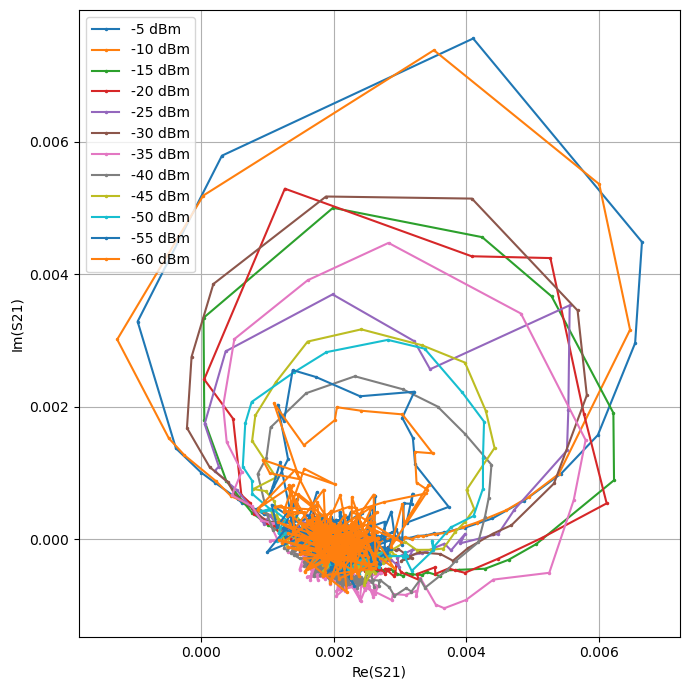


Saved results to:
C:\Users\user\Documents\GitHub\Measurements\Cooldown_77_Line2-MQC_Nb_Qc1M_01\most_recent_data\Resonator_7_7p007GHz\manual_circle_fit_results.csv


In [75]:
if __name__ == "__main__":

    folder_path = r"C:\Users\user\Documents\GitHub\Measurements\Cooldown_77_Line2-MQC_Nb_Qc1M_01\most_recent_data\Resonator_7_7p007GHz"

    Qc = 1e6  # update this

    results_df = fit_folder(folder_path=folder_path,Qc=Qc,draw_each_circle=False,)

    print("\nFinal results:")
    print(results_df)

    plot_all_complex_s21(folder_path)

    output_path = os.path.join(folder_path, "manual_circle_fit_results.csv")
    results_df.to_csv(output_path, index=False)

    print(f"\nSaved results to:")
    print(output_path)

    